# Notebook 1: Introduction to Deep Learning

**Goal:** Understand the key concepts behind deep learning before we start coding.

This notebook covers:
1. What is Machine Learning?
2. What is Deep Learning?
3. What is a Neural Network?
4. What is a CNN (Convolutional Neural Network)?
5. Why CIFAR-10?
6. Project Roadmap

---

## 1. What is Machine Learning?

**Traditional programming:** You write explicit rules.
```
IF pixel_color == red AND shape == round THEN label = 'apple'
```

**Machine Learning:** You show the computer many examples, and it *learns* the rules automatically.
```
Given: 1000 images labeled 'apple', 1000 labeled 'orange'
Output: A model that can classify NEW images it has never seen before
```

### Types of Machine Learning:
- **Supervised Learning** (what we're doing): We have labeled data (images + correct answers). The model learns to map inputs to outputs.
- **Unsupervised Learning**: No labels. The model finds patterns/groups on its own.
- **Reinforcement Learning**: The model learns by trial and error (rewards/penalties).

### Our Task: **Image Classification** (Supervised Learning)
- **Input:** A 32x32 pixel color image
- **Output:** One of 10 categories (airplane, car, bird, cat, etc.)
- **Training:** Show the model 50,000 labeled images
- **Testing:** Check if it correctly classifies 10,000 images it has never seen

## 2. What is Deep Learning?

Deep Learning is a **subset of Machine Learning** that uses neural networks with many layers (hence "deep").

```
Artificial Intelligence (AI)
    └── Machine Learning (ML)
            └── Deep Learning (DL)
                    └── CNNs, RNNs, Transformers, etc.
```

### Why is Deep Learning special?

Traditional ML requires **feature engineering** — a human expert manually designs what features to extract from data (e.g., "count the edges", "measure the color histogram").

Deep Learning **automatically learns features** from raw data. The network figures out on its own what patterns matter.

| Aspect | Traditional ML | Deep Learning |
|--------|---------------|---------------|
| Features | Hand-designed by humans | Learned automatically |
| Data needed | Can work with less data | Needs lots of data |
| Compute | Runs on basic hardware | Benefits from GPUs |
| Performance on images | OK (~40-55%) | Excellent (~85-99%) |
| Interpretability | Easier to understand | "Black box" |

## 3. What is a Neural Network?

A neural network is inspired by the human brain (loosely). It's made of **layers of neurons** connected to each other.

### A Single Neuron:
```
Inputs (x)    Weights (w)     Output
  x1 ──────── w1 ─┐
  x2 ──────── w2 ─┼──> SUM ──> Activation ──> y
  x3 ──────── w3 ─┘     + bias(b)
```

**How it works:**
1. Each input `x` is multiplied by a weight `w` (the weights are what the model LEARNS)
2. All weighted inputs are summed: `z = w1*x1 + w2*x2 + w3*x3 + b`
3. The sum passes through an **activation function**: `y = f(z)`

### Activation Functions:
The most common is **ReLU** (Rectified Linear Unit):
```
ReLU(x) = max(0, x)
- If x > 0: output = x  (pass through)
- If x ≤ 0: output = 0  (block)
```

**Why do we need activation functions?**
Without them, stacking layers would be pointless. Two linear transformations stacked = one linear transformation. Activation functions add **non-linearity**, allowing the network to learn complex, curved decision boundaries.

### A Neural Network = Many Neurons in Layers:
```
Input Layer      Hidden Layer 1    Hidden Layer 2    Output Layer
(raw pixels)     (learned feat.)   (higher feat.)    (class scores)

  o ─────────── o                                     o  airplane
  o ─────────── o ─────────── o                       o  car
  o ─────────── o ─────────── o ─────────── o         o  bird
  o ─────────── o ─────────── o                       ....
  o ─────────── o                                     o  truck
(3072)          (512)             (256)               (10)
```

## 4. What is a CNN (Convolutional Neural Network)?

A CNN is a special type of neural network designed specifically for **images**.

### The Problem with Regular Neural Networks for Images:
A 32x32 color image has 3,072 pixels. A regular (fully connected) network would need one weight for EVERY connection. With a hidden layer of 512 neurons:
- Connections = 3,072 × 512 = **1.5 million** weights just for the first layer!
- This is wasteful because nearby pixels are related, but distant pixels often aren't.

### CNNs Use **Convolution** — The Key Idea:

Instead of looking at ALL pixels at once, a CNN slides a small **filter** (also called a **kernel**) across the image and detects **local patterns**.

```
Image (5x5 pixels, simplified):     Filter (3x3):
┌───┬───┬───┬───┬───┐              ┌────┬────┬────┐
│ 1 │ 0 │ 1 │ 0 │ 0 │              │ 1  │ 0  │ -1 │
├───┼───┼───┼───┼───┤              ├────┼────┼────┤
│ 0 │ 1 │ 1 │ 1 │ 0 │              │ 1  │ 0  │ -1 │
├───┼───┼───┼───┼───┤              ├────┼────┼────┤
│ 0 │ 0 │ 1 │ 1 │ 0 │              │ 1  │ 0  │ -1 │
├───┼───┼───┼───┼───┤              └────┴────┴────┘
│ 1 │ 1 │ 0 │ 0 │ 1 │              This filter detects
├───┼───┼───┼───┼───┤              VERTICAL EDGES!
│ 0 │ 1 │ 1 │ 0 │ 0 │
└───┴───┴───┴───┴───┘

The filter slides across every 3x3 region of the image.
At each position, it computes: sum(filter × image_patch)
High value = strong match (edge detected here!)
```

### Why CNNs are Perfect for Images:
1. **Local connectivity:** Each neuron only looks at a small region (3x3), not the whole image
2. **Weight sharing:** The SAME filter is used everywhere in the image (far fewer parameters)
3. **Hierarchical features:** Early layers detect edges → Middle layers detect textures/shapes → Later layers detect objects

### CNN Building Blocks:

| Layer | What it does | Example |
|-------|-------------|----------|
| **Conv2d** | Slides filters to detect patterns | 32 filters of 3x3 → 32 feature maps |
| **BatchNorm** | Normalizes outputs for stable training | Makes mean≈0, std≈1 |
| **ReLU** | Activation: max(0, x) | Adds non-linearity |
| **MaxPool** | Shrinks spatial dimensions by taking max in 2x2 | 32x32 → 16x16 |
| **Dropout** | Randomly disables neurons during training | Prevents overfitting |
| **Linear** | Fully connected layer for final classification | 4096 → 10 classes |

### Interactive Demo: What Convolution Actually Does

Let's apply a real convolution filter to an image and see the result!

In [1]:
# First, let's set up our path so we can import from the src/ directory
# sys.path.insert(0, '..') adds the parent directory (project root) to Python's
# search path, so 'import src.data_utils' works from inside notebooks/
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torchvision

# Load one image from CIFAR-10 (without any transforms)
dataset = torchvision.datasets.CIFAR10(root='../data', train=True, download=True)

# Get a sample image (a deer, index 4)
# dataset[index] returns (PIL_Image, label)
sample_img, label = dataset[100]
img_array = np.array(sample_img)  # Convert PIL → numpy array, shape (32, 32, 3)

print(f"Image shape: {img_array.shape}")  # (32, 32, 3) = height, width, channels
print(f"Pixel value range: {img_array.min()} to {img_array.max()}")  # 0 to 255
print(f"Label: {dataset.classes[label]}")  # The class name

100%|██████████| 170M/170M [00:19<00:00, 8.94MB/s] 


Image shape: (32, 32, 3)
Pixel value range: 30 to 242
Label: ship


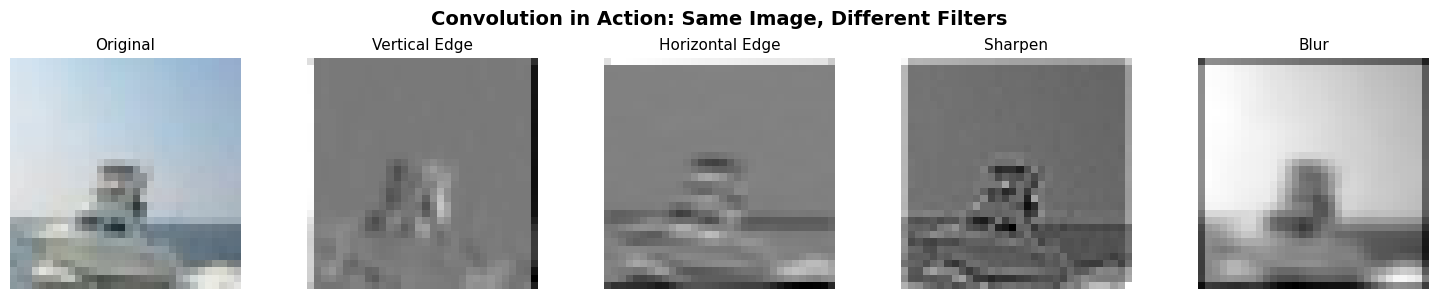


Key insight: Each filter detects a DIFFERENT pattern!
A CNN learns HUNDREDS of these filters automatically during training.
Early layers learn edges, later layers learn complex shapes and objects.


In [2]:
# Now let's define hand-crafted convolution filters and see what they detect!

# Convert image to a PyTorch tensor for convolution
# We need shape (1, 1, H, W) = (batch=1, channels=1, height, width)
# First, convert to grayscale by averaging the 3 color channels
gray = np.mean(img_array, axis=2)  # (32, 32, 3) → (32, 32)
img_tensor = torch.FloatTensor(gray).unsqueeze(0).unsqueeze(0)  # → (1, 1, 32, 32)

# Define 4 different filters (kernels)
filters = {
    'Vertical Edge': torch.FloatTensor([[-1, 0, 1],
                                        [-2, 0, 2],
                                        [-1, 0, 1]]),
    
    'Horizontal Edge': torch.FloatTensor([[-1, -2, -1],
                                          [ 0,  0,  0],
                                          [ 1,  2,  1]]),
    
    'Sharpen': torch.FloatTensor([[ 0, -1,  0],
                                  [-1,  5, -1],
                                  [ 0, -1,  0]]),
    
    'Blur': torch.FloatTensor([[1/9, 1/9, 1/9],
                               [1/9, 1/9, 1/9],
                               [1/9, 1/9, 1/9]]),
}

# Apply each filter using convolution and display results
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

# Show original image
axes[0].imshow(img_array)
axes[0].set_title('Original', fontsize=11)
axes[0].axis('off')

for i, (name, kernel) in enumerate(filters.items()):
    # Reshape kernel for conv2d: (out_channels=1, in_channels=1, H=3, W=3)
    kernel_tensor = kernel.unsqueeze(0).unsqueeze(0)
    
    # F.conv2d performs the convolution operation
    # padding=1 keeps the output the same size as input
    output = F.conv2d(img_tensor, kernel_tensor, padding=1)
    
    # Display the result
    axes[i+1].imshow(output.squeeze().numpy(), cmap='gray')
    axes[i+1].set_title(name, fontsize=11)
    axes[i+1].axis('off')

plt.suptitle('Convolution in Action: Same Image, Different Filters', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey insight: Each filter detects a DIFFERENT pattern!")
print("A CNN learns HUNDREDS of these filters automatically during training.")
print("Early layers learn edges, later layers learn complex shapes and objects.")

## 5. Why CIFAR-10?

CIFAR-10 is one of the most widely used benchmark datasets in deep learning.

**Dataset Facts:**
- **60,000** color images total (50,000 train + 10,000 test)
- **10 classes:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
- **32x32 pixels** per image (very small!)
- **3 color channels** (RGB)
- Perfectly balanced: 5,000 training images per class
- Created by Alex Krizhevsky in 2009 at the University of Toronto

**Why it's great for learning:**
- Small enough to train on a laptop CPU in ~30 minutes
- Complex enough to show the power of deep learning vs traditional ML
- Well-studied: we know what accuracy to expect (85-95% depending on model complexity)
- Built into PyTorch and TensorFlow — no manual download needed

**Known benchmarks:**
- Simple Logistic Regression: ~40% accuracy
- SVM: ~50% accuracy  
- Simple CNN (what we'll build): ~85-90% accuracy
- State-of-the-art (complex models): ~99% accuracy

## 6. Project Roadmap

Here's what we'll do across the remaining notebooks:

| Notebook | What We Do | What We Learn |
|----------|-----------|---------------|
| **02 - Data Exploration** | Load and visualize CIFAR-10 | How to explore and understand a dataset |
| **03 - ML Baseline** | Train Logistic Regression & SVM | Why traditional ML struggles with images |
| **04 - CNN Model** | Build, train, evaluate a CNN | How deep learning works in practice |
| **05 - Comparison** | Compare all models side by side | Why deep learning dominates computer vision |

Let's get started!